# Section 2 — Data Understanding

This notebook covers **2.1–2.5** for Submission 1.

## Setup: local files and documented dataset definitions

In [13]:
from pathlib import Path
from collections import Counter, defaultdict
from importlib.metadata import version
import json
import platform

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Works when launched from the project root or notebooks/ directory
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data" / "mitdb").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Extract MIT-BIH into project's data/mitdb/ folder.")
DATA_DIR = ROOT / "data" / "mitdb"
OUT_DIR = ROOT / "results" / "eda_ds1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Supplied development/test membership
DS1 = """101 106 108 109 112 114 115 116 118 119 122 124 201 203
205 207 208 209 215 220 223 230""".split()
DS2 = """100 103 105 111 113 117 121 123 200 202 210 212 213 214
219 221 222 228 231 232 233 234""".split()
PACED_RECORDS = ["102", "104", "107", "217"]
EXPECTED_RECORDS = set(DS1) | set(DS2) | set(PACED_RECORDS)

RECORDS = sorted({file.stem for ext in ["hea", "dat", "atr"]
                  for file in DATA_DIR.glob(f"*.{ext}") if file.stem.isdigit()})
if len(DS1) != 22 or len(DS2) != 22 or set(DS1) & set(DS2):
    raise ValueError("The supplied recording lists are inconsistent.")
if len(EXPECTED_RECORDS) != 48:
    raise ValueError("Expected 48 unique records in the supplied protocol.")

DATABASE_SOURCE = "https://physionet.org/content/mitdb/1.0.0/"
DIRECTORY_SOURCE = "https://physionet.org/physiobank/database/html/mitdbdir/intro.htm"
MAPPING_SOURCE = "https://www.tara.tcd.ie/bitstreams/10f1bc7f-63d3-4e50-b9c4-2fae0c985b04/download"

CLASSES = ["N", "S", "V", "F"]
MAPPING = {"N": ["N", "L", "R"],
           "S": ["A", "a", "J", "S", "e", "j"],
           "V": ["V", "E"], "F": ["F"]}
TO_CLASS = {symbol: cls for cls, symbols in MAPPING.items() for symbol in symbols}
BEAT_SYMBOLS = set(TO_CLASS) | {"/", "f", "Q"}
EXCLUDED = {
    "/": ("Excluded beat", "Paced beat"),
    "f": ("Excluded beat", "Fusion of paced and normal beat"),
    "Q": ("Excluded beat", "Unclassifiable beat"),
    "+": ("Non-beat annotation", "Rhythm change"),
    "~": ("Non-beat annotation", "Signal-quality change"),
    '"': ("Non-beat annotation", "Comment"),
    "x": ("Non-beat annotation", "Blocked P-wave"),
    "|": ("Non-beat annotation", "Isolated QRS-like artifact"),
    "!": ("Non-beat annotation", "Ventricular flutter wave"),
    "[": ("Non-beat annotation", "Start of ventricular flutter/fibrillation"),
    "]": ("Non-beat annotation", "End of ventricular flutter/fibrillation")
}
SEED = 42
PLOT_SAMPLES_PER_CHANNEL = 5000
DISPLAY_BEATS = 6               # Display choice: approximately six typical beat intervals.
rng = np.random.default_rng(SEED)
COLORS = {"N": "royalblue", "S": "darkorange", "V": "seagreen", "F": "crimson"}


def subject_key(record):
    return "201_202" if record in {"201", "202"} else record


def ds1_record_path(record):
    """Guarded every WFDB read: test and excluded records must not be opened."""
    if record not in DS1:
        raise ValueError(f"EDA is restricted to DS1; refusing to read {record}.")
    return str(DATA_DIR / record)


def save_table(name, table):
    table.to_csv(OUT_DIR / f"{name}.csv", index=False)


def finish_figure(name, fig):
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def quality_intervals(ann, length, channel):
    """Interpret ~ subtype bits; initial/unannotated quality remains unknown."""
    marks = [(int(p), int(code) & 255)
             for p, sym, code in zip(ann.sample, ann.symbol, ann.subtype)
             if sym == "~" and 0 <= p < length]
    intervals, start, state = [], 0, "unknown"
    for end, code in sorted(marks, key=lambda item: item[0]):
        if end > start:
            intervals.append((start, end, state))
        if code & (1 << (channel + 4)):
            state = "unreadable"
        elif code & (1 << channel):
            state = "noisy"
        else:
            state = "clean"
        start = end
    if start < length:
        intervals.append((start, length, state))
    return intervals


def longest_constant_run(digital, finite):
    """Exact repeated digital values; missing samples break the runs"""
    if not finite.any():
        return 0, 0
    change = (digital[1:] != digital[:-1]) | ~finite[1:] | ~finite[:-1]
    edges = np.r_[0, np.flatnonzero(change) + 1, len(digital)]
    sizes = np.where(finite[edges[:-1]], np.diff(edges), 0)
    best = int(np.argmax(sizes))
    return int(edges[best]), int(sizes[best])

## 2.1 Dataset Description

The project uses the MIT-BIH Arrhythmia Database, version 1.0.0.

The following information describes the complete database according
to its official documentation. Exploratory analysis uses DS1.

| Property | Published information |
|---|---|
| Database name | MIT-BIH Arrhythmia Database |
| Version | 1.0.0 |
| Number of recordings | 48 |
| Number of people | 47 |
| Channels per recording | 2 measurement views |
| Sampling frequency | 360 measurements per second per channel |
| Recording duration | Approximately 30 minutes per recording |
| Annotation type | Expert beat, rhythm, artifact and signal-quality labels stored in `.atr` files |
| Available ECG leads | MLII, V1, V2, V4 and V5 |

Sources:
- [PhysioNet database description](https://physionet.org/content/mitdb/1.0.0/)
- [MIT-BIH database directory](https://physionet.org/physiobank/database/html/mitdbdir/intro.htm)

The code below checks the downloaded files and calculates the
recording information for DS1.


In [14]:
# Check required recording files
file_rows = [{"record": rec, **{ext: (DATA_DIR / f"{rec}.{ext}").is_file()
                              for ext in ["hea", "dat", "atr"]}}
             for rec in sorted(EXPECTED_RECORDS | set(RECORDS))]
file_checks = pd.DataFrame(file_rows)
save_table("file_checks", file_checks)
unexpected = sorted(set(RECORDS) - EXPECTED_RECORDS)
if unexpected:
    raise ValueError(f"Unexpected numeric record IDs in data/mitdb: {unexpected}")
missing = file_checks.loc[~file_checks[["hea", "dat", "atr"]].all(axis=1)]
if not missing.empty:
    print(missing.to_string(index=False))
    raise FileNotFoundError("Incomplete dataset. Missing files are listed above and in file_checks.csv.")

manifest = pd.DataFrame([
    {"record": rec, "subject_key": subject_key(rec),
     "group": "DS1" if rec in DS1 else "DS2" if rec in DS2 else "Excluded paced record"}
    for rec in RECORDS])
save_table("supplied_record_manifest", manifest)
shared_subjects = sorted({subject_key(rec) for rec in DS1} & {subject_key(rec) for rec in DS2})
print("Same-subject exception across supplied sets:", shared_subjects)

headers, annotations = {}, {}
metadata_rows, annotation_rows, count_rows = [], [], []
symbol_counts, rr_seconds = Counter(), []
for rec in DS1:
    try:
        h = wfdb.rdheader(ds1_record_path(rec))
        a = wfdb.rdann(ds1_record_path(rec), "atr")
    except Exception as error:
        save_table("read_errors", pd.DataFrame([{"record": rec, "error": str(error)}]))
        raise RuntimeError(f"Cannot read header/annotations for record {rec}.") from error
    headers[rec], annotations[rec] = h, a
    subject = subject_key(rec)
    metadata_rows.append({"record": rec, "subject_key": subject,
                          "channels": h.n_sig, "fs_Hz": h.fs, "samples": h.sig_len,
                          "duration_minutes": h.sig_len / h.fs / 60,
                          "leads": ", ".join(h.sig_name), "units": ", ".join(h.units)})
    counts = Counter(a.symbol)
    symbol_counts.update(counts)
    mapped = {cls: sum(counts[sym] for sym in MAPPING[cls]) for cls in CLASSES}
    count_rows.append({"record": rec, "subject_key": subject, **mapped,
                       "total": sum(mapped.values())})
    beat_positions = np.asarray([p for p, sym in zip(a.sample, a.symbol)
                                 if sym in BEAT_SYMBOLS and 0 <= p < h.sig_len])
    annotation_rows.append({"record": rec, "annotations": len(a.sample),
                            "out_of_range": int(((a.sample < 0) | (a.sample >= h.sig_len)).sum()),
                            "out_of_order": int((np.diff(a.sample) < 0).sum()),
                            "duplicate_beat_positions": len(beat_positions) - len(np.unique(beat_positions))})
    rr = np.diff(beat_positions) / h.fs
    rr_seconds.extend(rr[rr > 0])

metadata = pd.DataFrame(metadata_rows)
record_counts = pd.DataFrame(count_rows)
annotation_checks = pd.DataFrame(annotation_rows)
subject_counts = record_counts.groupby("subject_key", as_index=False)[CLASSES + ["total"]].sum()
all_leads = sorted({lead for h in headers.values() for lead in h.sig_name})
analysis_description = pd.DataFrame({
    "Metric": ["Analysis scope", "Records analysed", "Subject keys analysed", "Channels per record",
               "Sampling frequencies measured", "Recording duration range measured", "Observed DS1 leads"],
    "Value": ["DS1 only: headers, annotations and both ECG channels", len(metadata),
              metadata.subject_key.nunique(),
              ", ".join(map(str, sorted(metadata.channels.unique()))),
              ", ".join(f"{value:g} Hz" for value in sorted(metadata.fs_Hz.unique())),
              f"{metadata.duration_minutes.min():.3f}-{metadata.duration_minutes.max():.3f} minutes",
              ", ".join(all_leads)]})
for name, table in [("analysis_description_DS1", analysis_description), ("record_metadata_DS1", metadata),
                    ("record_class_counts_DS1", record_counts), ("subject_class_counts_DS1", subject_counts),
                    ("annotation_checks_DS1", annotation_checks)]:
    save_table(name, table)
print("\nMeasured development-set description\n", analysis_description.to_string(index=False))

Same-subject exception across supplied sets: ['201_202']

Measured development-set description
                            Metric                                                Value
                   Analysis scope DS1 only: headers, annotations and both ECG channels
                 Records analysed                                                   22
            Subject keys analysed                                                   22
              Channels per record                                                    2
    Sampling frequencies measured                                               360 Hz
Recording duration range measured                                30.093-30.093 minutes
               Observed DS1 leads                                     MLII, V1, V4, V5


## 2.2 Target classes and documented exclusions

In [15]:
totals = record_counts[CLASSES].sum()
if int(totals.sum()) == 0:
    raise ValueError("No N/S/V/F beat annotations were found in DS1.")
target_classes = pd.DataFrame({"Final class": CLASSES,
                               "Original annotations included": [", ".join(MAPPING[c]) for c in CLASSES],
                               "Number of beats": [int(totals[c]) for c in CLASSES],
                               "Percentage": [100 * totals[c] / totals.sum() for c in CLASSES]})
excluded_rows = []
for sym, count in symbol_counts.items():
    if sym not in TO_CLASS:
        category, meaning = EXCLUDED.get(sym, ("Requires review", "Unrecognised annotation: inspect documentation"))
        excluded_rows.append({"symbol": sym, "category": category, "meaning": meaning, "count": count})
excluded_table = pd.DataFrame(excluded_rows, columns=["symbol", "category", "meaning", "count"])
excluded_table = excluded_table.sort_values("count", ascending=False)
assert int(totals.sum()) + int(excluded_table["count"].sum()) == sum(symbol_counts.values())
save_table("target_classes_DS1", target_classes)
save_table("excluded_annotations_DS1", excluded_table)
print("\n2.2 Target classes: DS1 only\n", target_classes.round(3).to_string(index=False))
print("\nExcluded annotations\n", excluded_table.to_string(index=False))
print("Excluded beat types fall outside N/S/V/F; non-beat events are not heartbeat targets.")
print("These are raw annotation counts, before extraction or preprocessing.")
print(f"N:F ratio = {totals['N'] / totals['F']:.1f}:1")


2.2 Target classes: DS1 only
 Final class Original annotations included  Number of beats  Percentage
          N                       N, L, R            45834      89.848
          S              A, a, J, S, e, j              976       1.913
          V                          V, E             3788       7.426
          F                             F              415       0.814

Excluded annotations
 symbol            category                                   meaning  count
     + Non-beat annotation                             Rhythm change    616
     ! Non-beat annotation                  Ventricular flutter wave    472
     ~ Non-beat annotation                     Signal-quality change    289
     | Non-beat annotation                Isolated QRS-like artifact     66
     x Non-beat annotation                            Blocked P-wave     58
     Q       Excluded beat                       Unclassifiable beat      8
     [ Non-beat annotation Start of ventricular flutter/fib

## 2.3-2.4 Scan full DS1 signals, derive display windows, collect quality evidence

In [16]:
if not rr_seconds:
    raise ValueError("No positive beat intervals were found in DS1.")
median_rr = float(np.median(rr_seconds))
# Using the median beat interval to set display windows
print(f"\nDS1 median beat interval: {median_rr:.4f} seconds")
quality_rows, interval_rows, error_rows = [], [], []
amplitudes = defaultdict(list)
beat_examples, segment_examples = {}, {}
for number, rec in enumerate(DS1, 1):
    print(f"Inspecting DS1 record {rec} ({number}/{len(DS1)})")
    h, a = headers[rec], annotations[rec]
    try:
        r = wfdb.rdrecord(ds1_record_path(rec), physical=False)
        digital = r.d_signal
        signal = r.dac()
        if signal.shape != (h.sig_len, h.n_sig):
            raise ValueError("Signal shape does not match the header.")
        if any(unit != "mV" for unit in r.units):
            raise ValueError("Unexpected amplitude units. Convert to mV before comparing.")
    except Exception as error:
        error_rows.append({"record": rec, "error": str(error)})
        continue
    half_window = max(1, round(median_rr * r.fs / 2))
    display_length = max(1, round(DISPLAY_BEATS * median_rr * r.fs))
    intervals_by_channel = {}
    for channel, lead in enumerate(r.sig_name):
        x, d = signal[:, channel], digital[:, channel]
        finite = np.isfinite(x)
        values = x[finite]
        intervals = quality_intervals(a, len(x), channel)
        intervals_by_channel[channel] = intervals
        state_samples = Counter()
        for start, end, state in intervals:
            state_samples[state] += end - start
            interval_rows.append({"record": rec, "channel": channel, "lead": lead, "state": state,
                                  "start_s": start / r.fs, "end_s": end / r.fs,
                                  "duration_s": (end - start) / r.fs})
            if state in {"clean", "noisy", "unreadable"}:
                length = min(display_length, end - start)
                left = start + (end - start - length) // 2
                snippet = x[left:left + length]
                score = (lead == "MLII", end - start)
                old = segment_examples.get(state)
                if (state != "clean" or np.isfinite(snippet).all()) and (old is None or score > old["score"]):
                    segment_examples[state] = {"record": rec, "channel": channel, "lead": lead,
                                               "start": left, "fs": r.fs, "signal": snippet.copy(), "score": score}
        q = np.quantile(values, [0, .25, .5, .75, 1]) if len(values) else np.full(5, np.nan)
        constant_start, constant_samples = longest_constant_run(d, finite)
        jumps = np.abs(np.diff(x))
        valid_jumps = np.flatnonzero(np.isfinite(jumps))
        jump_index = int(valid_jumps[np.argmax(jumps[valid_jumps])]) if len(valid_jumps) else None
        bits, zero = h.adc_res[channel], h.adc_zero[channel]
        if bits is not None and bits > 0 and zero is not None:
            lower, upper = zero - 2 ** (bits - 1), zero + 2 ** (bits - 1) - 1
            rail_samples = int((finite & ((d <= lower) | (d >= upper))).sum())
        else:
            rail_samples = np.nan
        expected = h.checksum[channel]
        checksum_ok = ((int(d.sum(dtype=np.int64)) & 65535) == (int(expected) & 65535)) if expected is not None else None
        quality_rows.append({"record": rec, "channel": channel, "lead": lead,
                             "samples": len(x), "nan_samples": int(np.isnan(x).sum()),
                             "inf_samples": int(np.isinf(x).sum()),
                             "min_mV": q[0], "q25_mV": q[1], "median_mV": q[2],
                             "q75_mV": q[3], "max_mV": q[4],
                             "std_mV": float(values.std()) if len(values) else np.nan,
                             "possible_rail_samples": rail_samples, "checksum_ok": checksum_ok,
                             "longest_constant_s": constant_samples / r.fs,
                             "constant_start_s": constant_start / r.fs,
                             "constant_exceeds_typical_RR": constant_samples / r.fs >= median_rr,
                             "max_jump_mV": float(jumps[jump_index]) if jump_index is not None else np.nan,
                             "max_jump_time_s": (jump_index + 1) / r.fs if jump_index is not None else np.nan,
                             **{f"{state}_pct": 100 * state_samples[state] / len(x)
                                for state in ["clean", "noisy", "unreadable", "unknown"]}})
        if len(values):
            sample = rng.choice(values, size=min(PLOT_SAMPLES_PER_CHANNEL, len(values)), replace=False)
            amplitudes[lead].append(sample)
    # Prefer MLII when available
    channel = r.sig_name.index("MLII") if "MLII" in r.sig_name else 0
    for p, sym in zip(a.sample, a.symbol):
        cls = TO_CLASS.get(sym)
        left, right = int(p) - half_window, int(p) + half_window
        if cls is None or left < 0 or right > r.sig_len:
            continue
        snippet = signal[left:right, channel]
        if not np.isfinite(snippet).all():
            continue
        clean = any(start <= left and right <= end and state == "clean"
                    for start, end, state in intervals_by_channel[channel])
        old = beat_examples.get(cls)
        if old is None or (clean and not old["annotated_clean"]):
            beat_examples[cls] = {"class": cls, "symbol": sym, "record": rec, "lead": r.sig_name[channel],
                                  "sample": int(p), "fs": r.fs, "half_window": half_window,
                                  "annotated_clean": clean, "signal": snippet.copy()}

quality = pd.DataFrame(quality_rows)
quality_regions = pd.DataFrame(interval_rows)
signal_errors = pd.DataFrame(error_rows, columns=["record", "error"])
save_table("signal_read_errors", signal_errors)
if quality.empty:
    raise RuntimeError("No DS1 signals could be read, inspect signal_read_errors.csv.")
save_table("signal_quality_DS1", quality)
save_table("quality_intervals_DS1", quality_regions)
example_table = pd.DataFrame([{k: v for k, v in item.items() if k != "signal"}
                              for item in beat_examples.values()])
save_table("heartbeat_examples_DS1", example_table)



DS1 median beat interval: 0.7389 seconds
Inspecting DS1 record 101 (1/22)
Inspecting DS1 record 106 (2/22)
Inspecting DS1 record 108 (3/22)
Inspecting DS1 record 109 (4/22)
Inspecting DS1 record 112 (5/22)
Inspecting DS1 record 114 (6/22)
Inspecting DS1 record 115 (7/22)
Inspecting DS1 record 116 (8/22)
Inspecting DS1 record 118 (9/22)
Inspecting DS1 record 119 (10/22)
Inspecting DS1 record 122 (11/22)
Inspecting DS1 record 124 (12/22)
Inspecting DS1 record 201 (13/22)
Inspecting DS1 record 203 (14/22)
Inspecting DS1 record 205 (15/22)
Inspecting DS1 record 207 (16/22)
Inspecting DS1 record 208 (17/22)
Inspecting DS1 record 209 (18/22)
Inspecting DS1 record 215 (19/22)
Inspecting DS1 record 220 (20/22)
Inspecting DS1 record 223 (21/22)
Inspecting DS1 record 230 (22/22)


## 2.3 EDA plots

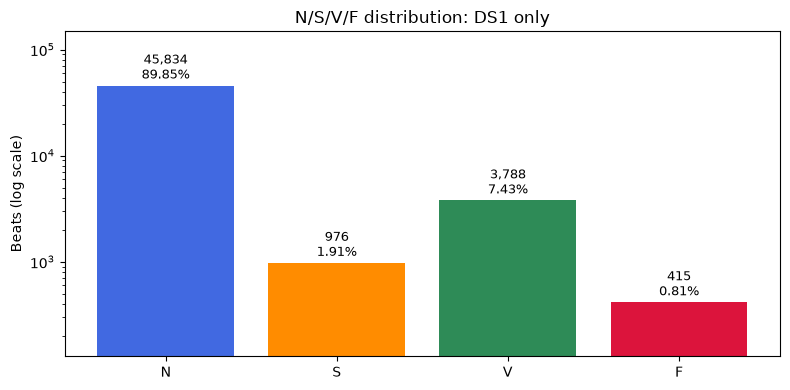

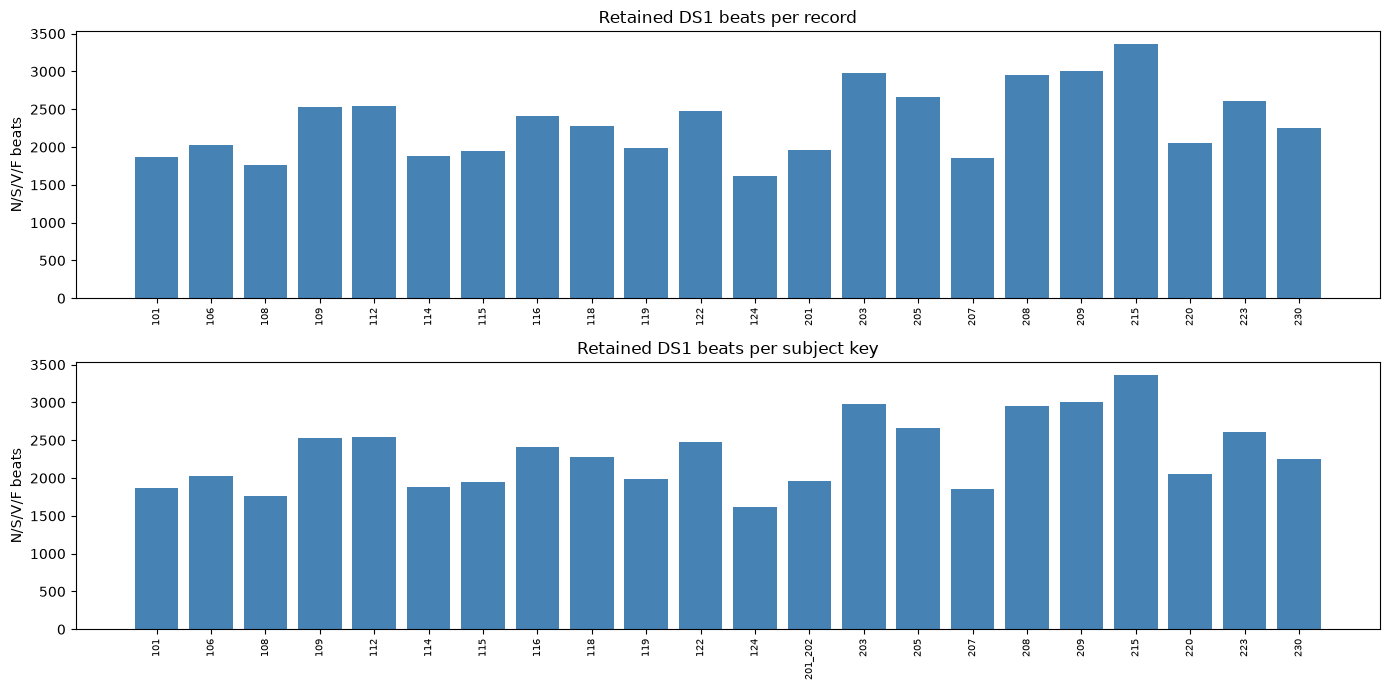

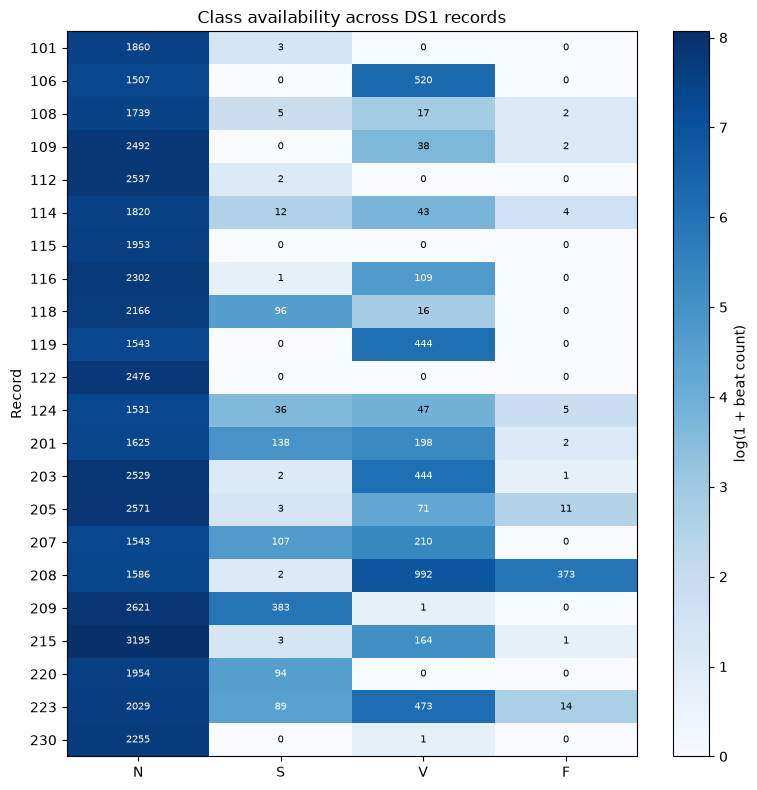

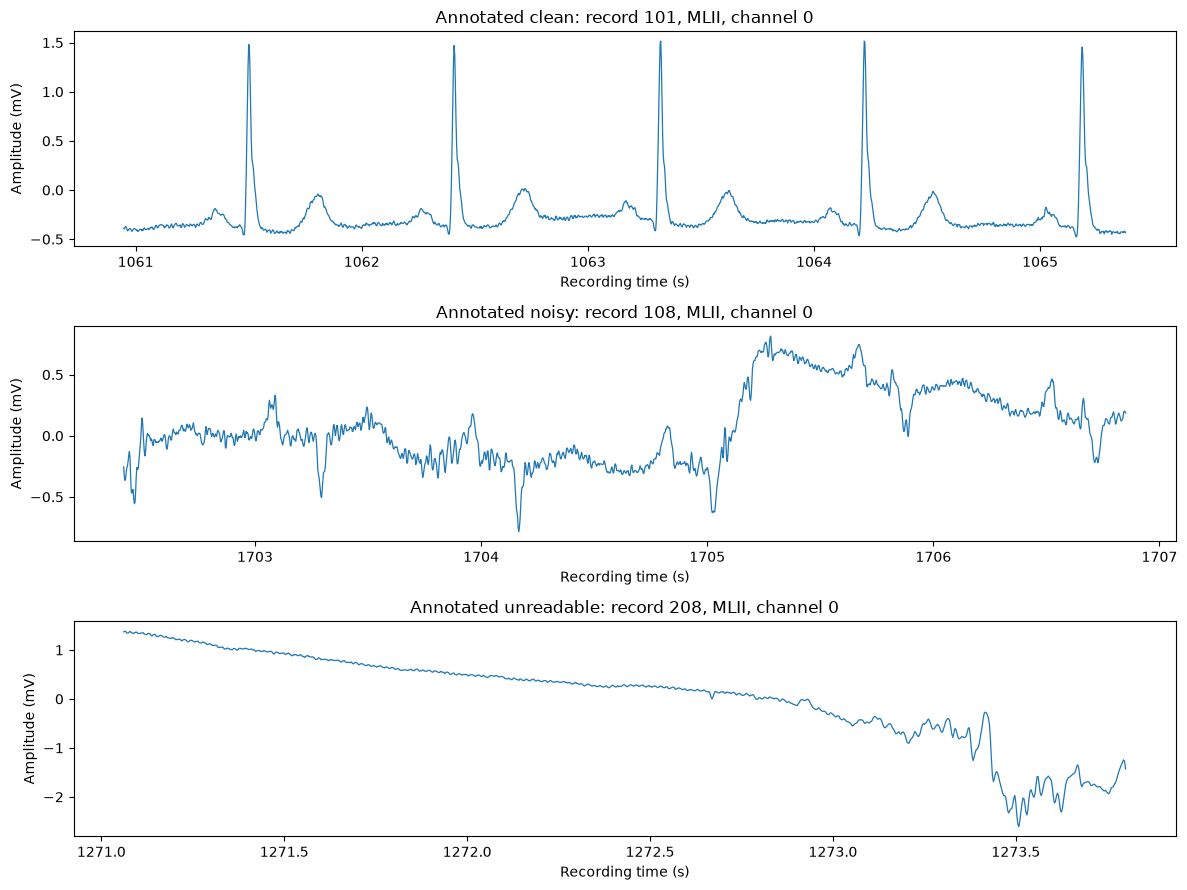

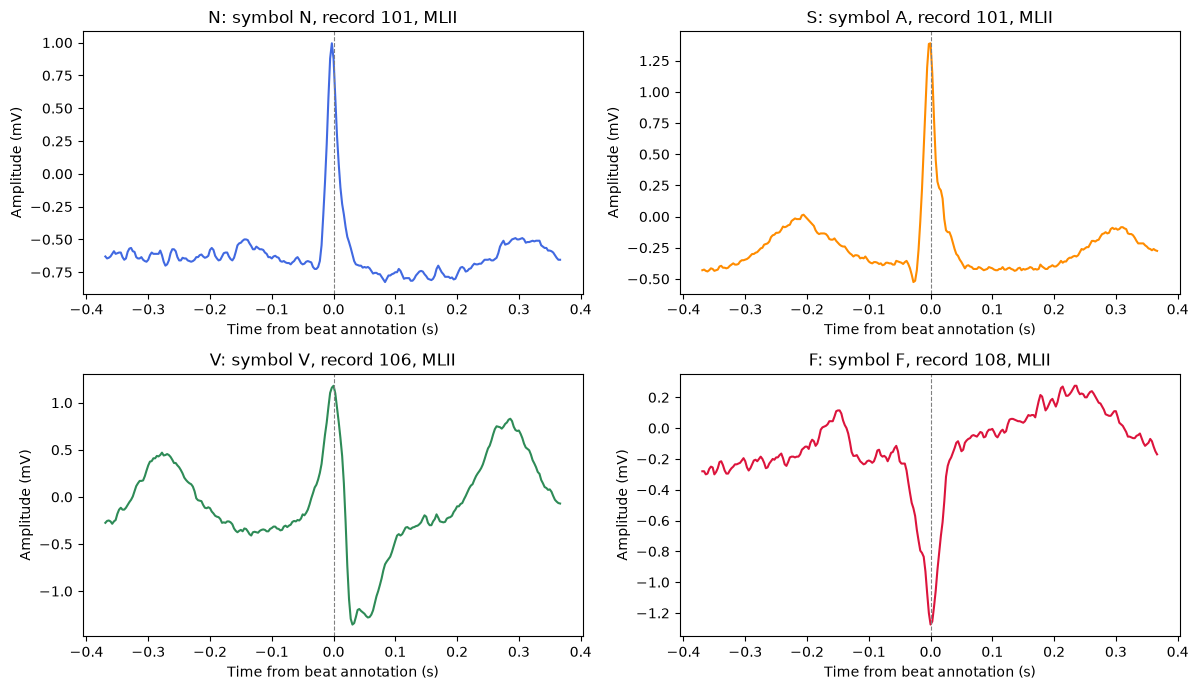

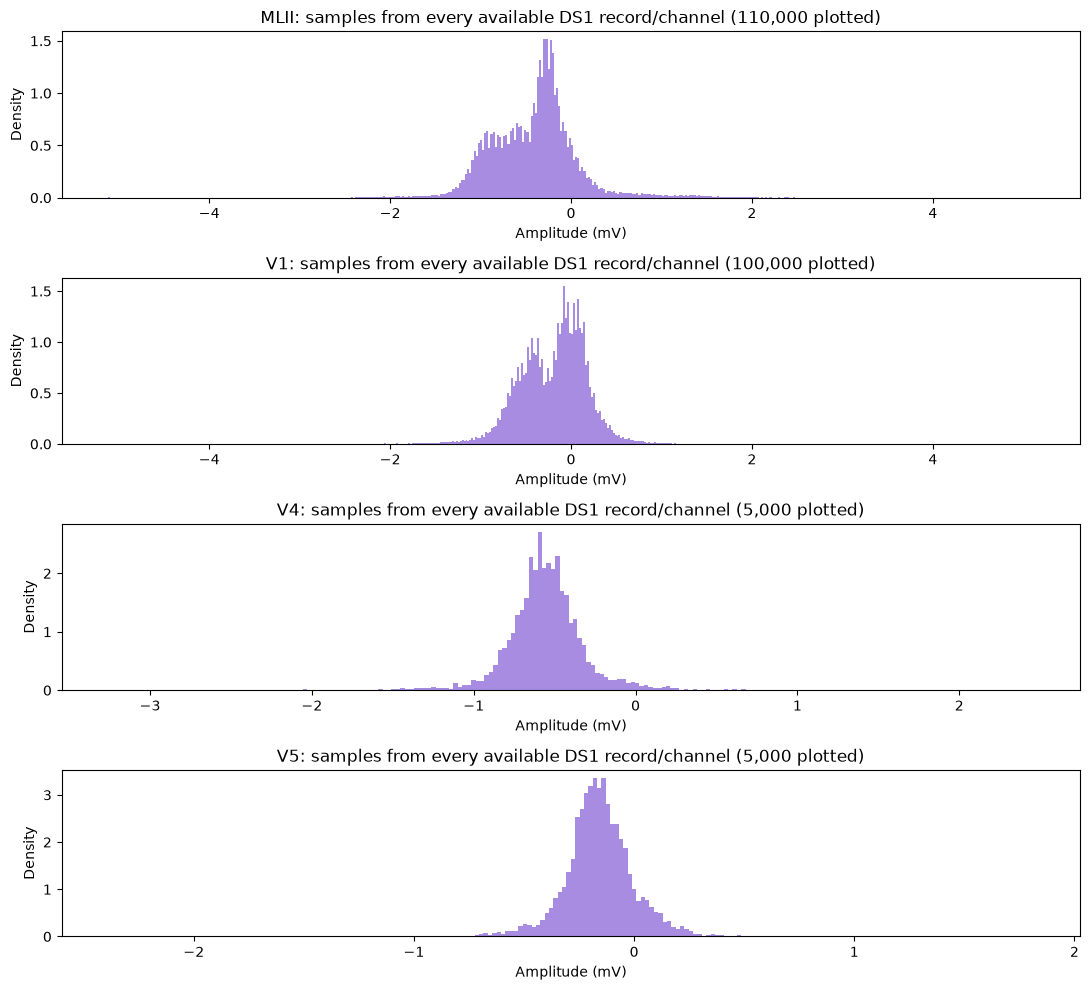

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(CLASSES, totals[CLASSES], color=[COLORS[c] for c in CLASSES])
ax.set_yscale("log")
ax.set(title="N/S/V/F distribution: DS1 only", ylabel="Beats (log scale)")
for bar, cls in zip(bars, CLASSES):
    ax.annotate(f"{totals[cls]:,}\n{100 * totals[cls] / totals.sum():.2f}%",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha="center", fontsize=9)
ax.margins(y=.25)
finish_figure("class_distribution", fig)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, table, key, title in [(axes[0], record_counts, "record", "Retained DS1 beats per record"),
                              (axes[1], subject_counts, "subject_key", "Retained DS1 beats per subject key")]:
    ax.bar(table[key], table["total"], color="steelblue")
    ax.set(title=title, ylabel="N/S/V/F beats")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
finish_figure("record_subject_distribution", fig)

development_counts = record_counts.set_index("record").loc[DS1, CLASSES]
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(np.log1p(development_counts.to_numpy()), aspect="auto", cmap="Blues")
ax.set_xticks(range(4), CLASSES)
ax.set_yticks(range(len(DS1)), DS1)
for i in range(len(DS1)):
    for j in range(4):
        ax.text(j, i, str(development_counts.iloc[i, j]), ha="center", va="center", fontsize=7,
                color="white" if im.get_array()[i, j] > im.get_array().max() / 2 else "black")
ax.set(title="Class availability across DS1 records", ylabel="Record")
fig.colorbar(im, ax=ax, label="log(1 + beat count)")
finish_figure("class_by_record_DS1", fig)

states = [state for state in ["clean", "noisy", "unreadable"] if state in segment_examples]
if states:
    fig, axes = plt.subplots(len(states), 1, figsize=(12, 3 * len(states)), squeeze=False)
    for ax, state in zip(axes[:, 0], states):
        item = segment_examples[state]
        time = (item["start"] + np.arange(len(item["signal"]))) / item["fs"]
        ax.plot(time, item["signal"], lw=.9)
        ax.set(title=f"Annotated {state}: record {item['record']}, {item['lead']}, channel {item['channel']}",
               xlabel="Recording time (s)", ylabel="Amplitude (mV)")
    finish_figure("ecg_quality_examples_DS1", fig)
else:
    print("No annotated ECG-quality examples were found.")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, cls in zip(axes.flat, CLASSES):
    if cls not in beat_examples:
        ax.text(.5, .5, f"No valid {cls} example found", ha="center", transform=ax.transAxes)
        continue
    item = beat_examples[cls]
    time = np.arange(-item["half_window"], item["half_window"]) / item["fs"]
    ax.plot(time, item["signal"], color=COLORS[cls])
    ax.axvline(0, color="grey", ls="--", lw=.8)
    ax.set(title=f"{cls}: symbol {item['symbol']}, record {item['record']}, {item['lead']}",
           xlabel="Time from beat annotation (s)", ylabel="Amplitude (mV)")
finish_figure("heartbeat_examples_DS1", fig)

leads = sorted(amplitudes)
fig, axes = plt.subplots(len(leads), 1, figsize=(11, 2.5 * len(leads)), squeeze=False)
for ax, lead in zip(axes[:, 0], leads):
    values = np.concatenate(amplitudes[lead])
    limits = quality.loc[quality.lead == lead]
    low, high = float(limits.min_mV.min()), float(limits.max_mV.max())
    ax.hist(values, bins="fd", range=(low, high) if low < high else None,
            density=True, color="mediumpurple", alpha=.8)
    ax.set(title=f"{lead}: samples from every available DS1 record/channel ({len(values):,} plotted)",
           xlabel="Amplitude (mV)", ylabel="Density")
finish_figure("amplitude_distributions_DS1", fig)

## 2.4 Quality summaries and recording/channel comparisons

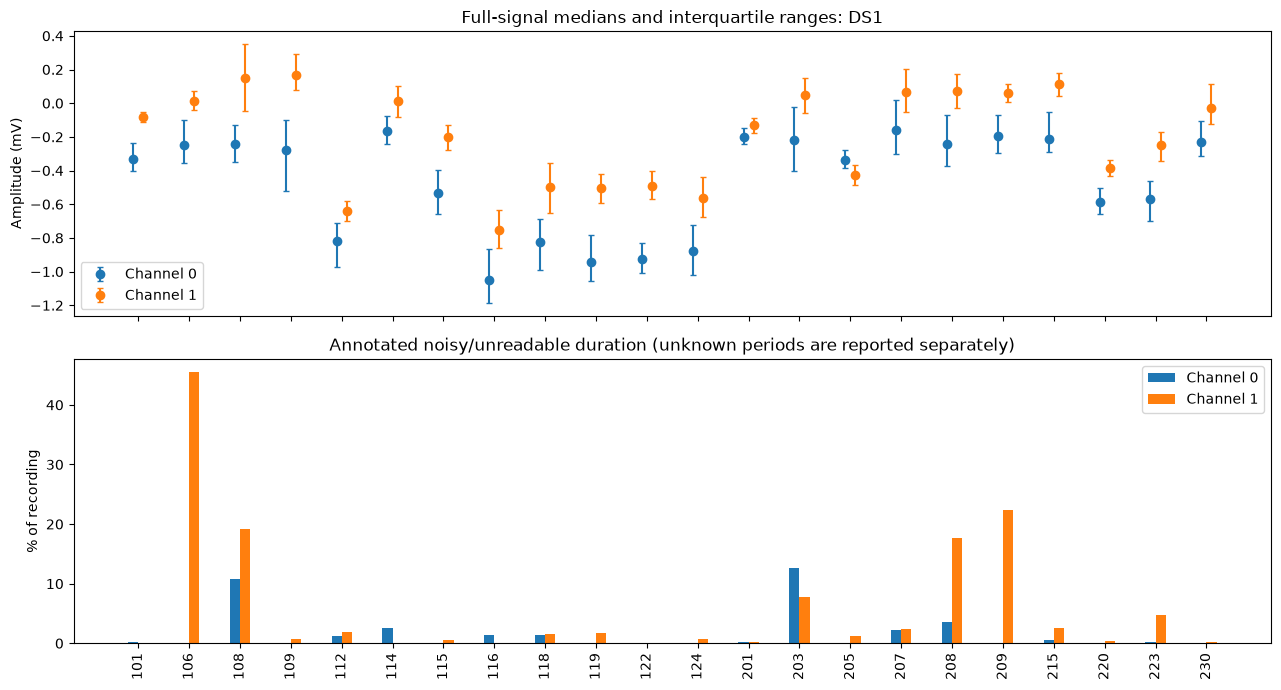

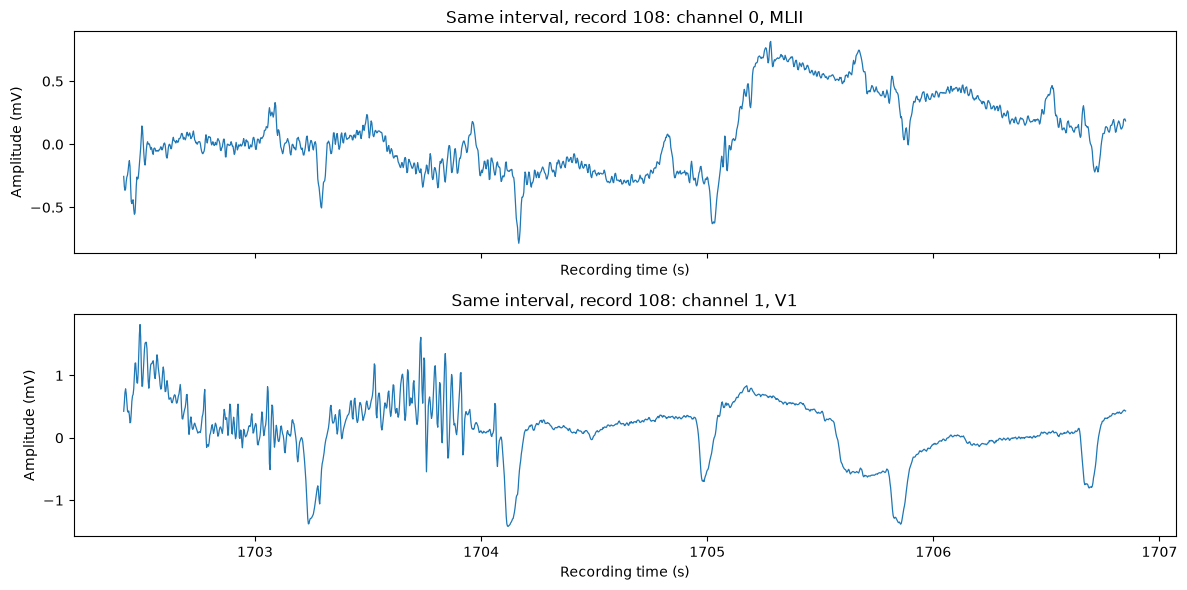


2.4 Quality summary
                                      Check                  Result
                     Detailed signal scope DS1 only; both channels
             Successfully read DS1 records                      22
                        Signal read errors                       0
                               NaN samples                       0
                          Infinite samples                       0
                Header checksum mismatches                       0
                 Possible ADC rail samples                    1635
Channels with a constant run >= typical RR                       0
   Out-of-range annotation positions (DS1)                       0
            Out-of-order annotations (DS1)                       0
            Duplicate beat positions (DS1)                       0

Largest observed amplitudes (all samples examined):
record  channel lead  min_mV  max_mV  max_jump_mV
   116        0 MLII  -5.120   5.115        0.640
   223        1   V1 

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
positions = {rec: i for i, rec in enumerate(DS1)}
for channel, group in quality.groupby("channel"):
    x = group.record.map(positions).to_numpy() + (channel - .5) * .2
    axes[0].errorbar(x, group.median_mV,
                    yerr=np.vstack([group.median_mV - group.q25_mV, group.q75_mV - group.median_mV]),
                    fmt="o", capsize=2, label=f"Channel {channel}")
    axes[1].bar(x, group.noisy_pct + group.unreadable_pct, width=.2, label=f"Channel {channel}")
axes[0].set(title="Full-signal medians and interquartile ranges: DS1", ylabel="Amplitude (mV)")
axes[1].set(title="Annotated noisy/unreadable duration (unknown periods are reported separately)",
            ylabel="% of recording")
axes[1].set_xticks(range(len(DS1)), DS1, rotation=90)
for ax in axes:
    ax.legend()
finish_figure("record_channel_comparison_DS1", fig)

if "noisy" in segment_examples:
    item = segment_examples["noisy"]
    pair = wfdb.rdrecord(ds1_record_path(item["record"]), sampfrom=item["start"],
                         sampto=item["start"] + len(item["signal"]))
    fig, axes = plt.subplots(pair.n_sig, 1, figsize=(12, 3 * pair.n_sig), squeeze=False, sharex=True)
    time = (item["start"] + np.arange(pair.sig_len)) / pair.fs
    for channel, ax in enumerate(axes[:, 0]):
        ax.plot(time, pair.p_signal[:, channel], lw=.9)
        ax.set(title=f"Same interval, record {item['record']}: channel {channel}, {pair.sig_name[channel]}",
               xlabel="Recording time (s)", ylabel="Amplitude (mV)")
    finish_figure("paired_channels_noisy_interval_DS1", fig)

summary = pd.DataFrame({"Check": ["Detailed signal scope", "Successfully read DS1 records", "Signal read errors",
                                 "NaN samples", "Infinite samples", "Header checksum mismatches",
                                 "Possible ADC rail samples", "Channels with a constant run >= typical RR",
                                 "Out-of-range annotation positions (DS1)",
                                 "Out-of-order annotations (DS1)", "Duplicate beat positions (DS1)"],
                        "Result": ["DS1 only; both channels", quality.record.nunique(), len(signal_errors),
                                   int(quality.nan_samples.sum()), int(quality.inf_samples.sum()),
                                   int(quality.checksum_ok.eq(False).sum()), int(quality.possible_rail_samples.sum()),
                                   int(quality.constant_exceeds_typical_RR.sum()),
                                   int(annotation_checks.out_of_range.sum()), int(annotation_checks.out_of_order.sum()),
                                   int(annotation_checks.duplicate_beat_positions.sum())]})
save_table("quality_summary", summary)
print("\n2.4 Quality summary\n", summary.to_string(index=False))
print("\nLargest observed amplitudes (all samples examined):")
extremes = quality.assign(max_absolute_mV=np.maximum(abs(quality.min_mV), abs(quality.max_mV)))
print(extremes.nlargest(8, "max_absolute_mV")[["record", "channel", "lead", "min_mV", "max_mV", "max_jump_mV"]].to_string(index=False))
print("\nBeat example provenance\n", example_table.to_string(index=False))

if not signal_errors.empty:
    print("\nRead failures: quality results are incomplete for these records:\n", signal_errors.to_string(index=False))
parameters = {"database_version": "1.0.0", "inventory_records": RECORDS,
              "inventory_method": "Local filenames and existence checks only",
              "analysis_records": DS1, "reserved_test_records": DS2,
              "excluded_record_ids": PACED_RECORDS, "mapping": MAPPING,
              "mapping_reference": "de Chazal et al. (2004), Table I", "mapping_source": MAPPING_SOURCE,
              "database_sources": [DATABASE_SOURCE, DIRECTORY_SOURCE],
              "DS2_contents_read": False, "shared_subjects_in_supplied_sets": shared_subjects,
              "random_seed": SEED, "plot_samples_per_record_channel": PLOT_SAMPLES_PER_CHANNEL,
              "display_beat_intervals": DISPLAY_BEATS, "median_RR_seconds_DS1": median_rr,
              "heartbeat_half_window_seconds": median_rr / 2, "histogram_bins": "Freedman-Diaconis",
              "initial_quality_state": "unknown", "subject_alias": {"201": "201_202", "202": "201_202"},
              "python": platform.python_version(),
              "packages": {name: version(name) for name in ["wfdb", "numpy", "pandas", "matplotlib"]}}
(OUT_DIR / "eda_parameters.json").write_text(json.dumps(parameters, indent=2), encoding="utf-8")
print(f"\nTables, figures and reproducibility settings saved in: {OUT_DIR}")


## 2.5 Leakage Analysis

Randomly splitting individual heartbeats from the same person between training and testing can produce misleading results. These beats can share characteristic shapes and recording conditions. A model may recognise familiar patterns from that person, making its test performance appear better than its performance on people it has never encountered. Separating beats does not necessarily separate people.

Other possible leakage routes include using test data to choose preprocessing or model settings, calculating normalisation statistics from combined training and test data, and placing an original beat and its augmented copies in different groups.

Our exploratory analysis is restricted to the 22 DS1 recordings. Every header, annotation and waveform read uses a function that rejects
recordings outside DS1. For DS2, only filenames and file availability are checked. Its signals and annotations do not contribute to our
measured class counts, amplitude statistics, example selection or display-window calculation. This prevents direct use of DS2 recording
contents during the EDA. Our evaluation design follows the supplied record-based DS1/DS2 partition. All heartbeats from a recording belong to its assigned group, rather than being randomly distributed between development and testing. During EDA, a reading guard also prevents DS2 recording contents from being accessed.

The supplied DS1/DS2 partition nevertheless contains one documented subject overlap i.e recordings 201 and 202 belong to the same person with 201 assigned to DS1 and 202 to DS2. A model trained on 201 and evaluated on 202 would therefore encounter a familiar person despite receiving a different recording. The supplied partition separates recordings but is not fully subject-independent. Our current analysis identifies this limitation; restricting access to DS2 alone does not eliminate it.

Source:
[MIT-BIH Arrhythmia Database documentation](https://physionet.org/physiobank/database/html/mitdbdir/intro.htm)
